In [1]:
from plntxps import *
import pandas as pd
import lmfit
import lmfext as lmfx
import re
from lmfitxps import models

data processed with plnt_xps version 0.1.1
our crew is replaceable, your package isn't!


In [2]:
def format_satellite_name(name):
    formatted_name = re.sub(r" ", "_", name)
    formatted_name = re.sub(r",", "", formatted_name)
    return formatted_name

satellites = pd.read_csv('example data/perkin elmer mg satellites.csv',
                sep = '\t').to_dict(orient='index')

for satellite in satellites.values():
    satellite['name'] = format_satellite_name(satellite['name'])

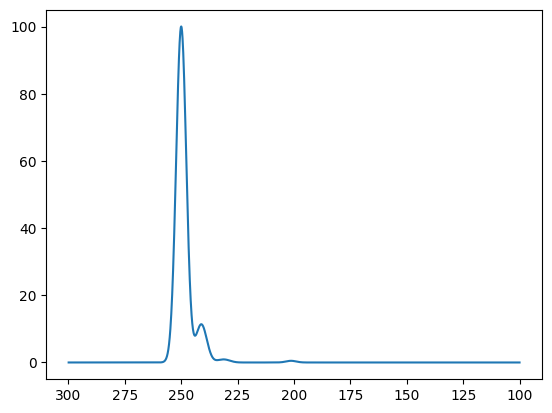

In [3]:
def source_peak(eV, shift, intensity):
    return np.exp(-((eV-250 + shift)**2)/10)*intensity

eV = np.arange(100, 300, 0.1)[::-1]
counts = np.zeros(len(eV))
for satellite in satellites.values():
    counts += source_peak(eV, satellite['position'], satellite['intensity'])
plt.plot(eV, counts)
plt.gca().invert_xaxis()

In [4]:
satellites

{0: {'name': 'alpha_1_2', 'position': 0.0, 'intensity': 100.0},
 1: {'name': 'alpha_3', 'position': 8.4, 'intensity': 8.0},
 2: {'name': 'alpha_4', 'position': 10.1, 'intensity': 4.1},
 3: {'name': 'alpha_5', 'position': 17.6, 'intensity': 0.6},
 4: {'name': 'alpha_6', 'position': 20.3, 'intensity': 0.5},
 5: {'name': 'beta', 'position': 48.7, 'intensity': 0.5}}

In [5]:
peak = models.ConvGaussianDoniachSinglett(prefix = "example_", independent_vars = ["x"])

In [6]:
peak.set_param_hint("amplitude", value = 50, min = 0)

In [7]:
def get_satellite_row(name, expr):
    result = {
        "Parameter": name,
        "value": "",
        "min": "",
        "max": "",
        "vary": "False",
        "expr": expr,
    }
    return result

def get_rows(parent_prefix, satellite):
    full_prefix = parent_prefix + satellite['name'] + '_'
    rows = []
    rows.append(get_satellite_row(f"{full_prefix}amplitude",
                f"{parent_prefix}amplitude*{satellite['intensity']}/100"))
    rows.append(get_satellite_row(f"{full_prefix}sigma", f"{parent_prefix}sigma"))
    rows.append(get_satellite_row(f"{full_prefix}gamma", f"{parent_prefix}gamma"))
    rows.append(get_satellite_row(f"{full_prefix}gaussian_sigma", f"{parent_prefix}gaussian_sigma"))
    rows.append(get_satellite_row(f"{full_prefix}center",
                f"{parent_prefix}center+{satellite['position']}"))
        
    rows.append(get_satellite_row(f"{full_prefix}gaussian_fwhm",
               f'2*{full_prefix}gaussian_sigma*1.1774'))
    rows.append(get_satellite_row(f"{full_prefix}lorentzian_fwhm",
               f'{full_prefix}sigma*(2+{full_prefix}gamma*2.5135+({full_prefix}gamma*3.6398)**4)'))

    return rows

In [8]:
satellite_params = []
for n in range (1, len(satellites)):
    satellite_params += get_rows("example_", satellites[n])
satellite_rows = pd.DataFrame(satellite_params)

In [9]:
origina_fit_file = pd.read_csv('example data/fit params.csv', sep = '\t')

In [10]:
(pd.concat([origina_fit_file, satellite_rows])
    .set_index('Parameter')
    .to_csv("example data/fit params with satellites.csv", sep = '\t'))

In [11]:
fit_models = []
fit_models.append(

_IncompleteInputError: incomplete input (402331510.py, line 2)